In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("customer_churn_nn.csv")
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [7]:
df.shape

(2000, 17)

In [8]:
df.columns

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [10]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [11]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [12]:
df["churn"].value_counts()

,count
churn,
0,1969
1,31


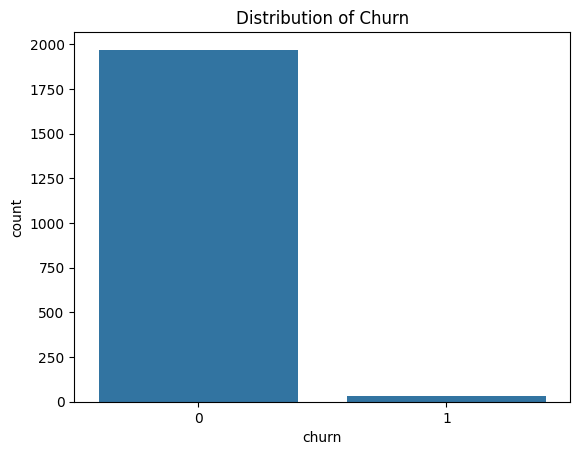

In [13]:
sns.countplot(x="churn", data=df)
plt.title("Distribution of Churn")
plt.show()

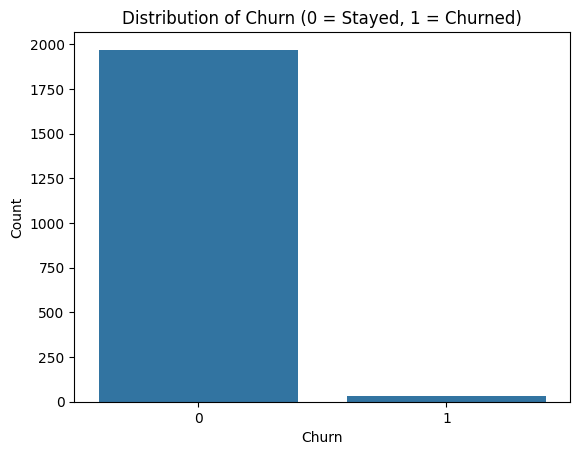

Churn value counts:
churn
0    1969
1      31
Name: count, dtype: int64

Churn percentage:
churn
0    98.45
1     1.55
Name: proportion, dtype: float64


In [14]:
sns.countplot(x="churn", data=df)
plt.title("Distribution of Churn (0 = Stayed, 1 = Churned)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

print("Churn value counts:")
print(df["churn"].value_counts())
print("\nChurn percentage:")
print(df["churn"].value_counts(normalize=True) * 100)

TASK - 2


In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Drop customer_id (not useful for model)
df = df.drop(columns=["customer_id"])

# Step 2: Encode categorical columns
cat_cols = ["region", "plan_type", "contract_type", "payment_method"]
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("After encoding:")
print(df.head())

After encoding:
   region  plan_type  contract_type  payment_method  tenure_months  \
0       3          3              0               1             30   
1       4          2              0               4             15   
2       0          3              0               0             72   
3       4          2              0               0             22   
4       2          2              0               2             11   

   monthly_charges_inr  avg_login_days_per_month  \
0               687.40                        13   
1              1029.74                        22   
2               732.07                        13   
3               959.51                        19   
4               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0         

In [16]:
# Step 3: Separate features and target
X = df.drop(columns=["churn"])
y = df["churn"]

# Step 4: Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training churn distribution:")
print(y_train.value_counts())

Training set size: (1600, 15)
Testing set size: (400, 15)
Training churn distribution:
churn
0    1575
1      25
Name: count, dtype: int64


TASK - 3


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix random seed for reproducibility
tf.random.set_seed(42)

# Build the model
model = keras.Sequential([
    layers.Input(shape=(15,)),                          # Input layer - 15 features
    layers.Dense(64, activation='relu'),                # Hidden layer 1
    layers.Dense(32, activation='relu'),                # Hidden layer 2
    layers.Dense(1, activation='sigmoid')               # Output layer (binary classification)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

TASK - 4

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("customer_churn_nn.csv")

df = df.drop(columns=["customer_id"])

cat_cols = ["region", "plan_type", "contract_type", "payment_method"]
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=["churn"])
y = df["churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(1600, 15) (400, 15)
churn
0    1575
1      25
Name: count, dtype: int64


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [20]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(15,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from sklearn.utils.class_weight import compute_class_weight

In [24]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.5079365079365079), 1: np.float64(32.0)}


In [25]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7417 - loss: 0.7843 - val_accuracy: 0.7812 - val_loss: 0.6174
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7451 - loss: 0.6646 - val_accuracy: 0.6500 - val_loss: 0.6313
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7292 - loss: 0.6000 - val_accuracy: 0.6562 - val_loss: 0.6253
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.5466 - val_accuracy: 0.6938 - val_loss: 0.5894
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.4977 - val_accuracy: 0.7375 - val_loss: 0.5407
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8076 - loss: 0.4509 - val_accuracy: 0.7563 - val_loss: 0.4868
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8306 - loss: 0.4094 - val_accuracy: 0.7812 - val_loss: 0.4479
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8438 - loss: 0.3715 - val_accuracy: 0.8188 - val_loss:

In [26]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Training Loss:", train_loss)
print("Testing Accuracy:", test_acc)
print("Testing Loss:", test_loss)

Training Accuracy: 0.9868749976158142
Training Loss: 0.04198151454329491
Testing Accuracy: 0.9599999785423279
Testing Loss: 0.1199735626578331


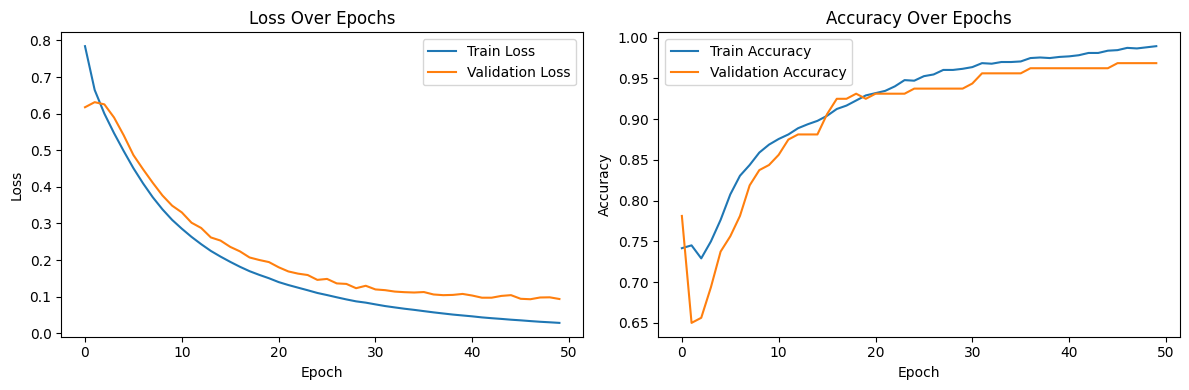

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "Hidden Layers": [1, 2, 3],
    "Neurons": ["32", "64,32", "128,64,32"],
    "Batch Size": [32, 32, 16],
    "Epochs": [30, 50, 50],
    "Test Accuracy": [0.8650, 0.9625, 0.9700]
})

print(results)

results.to_csv("model_comparison_table.csv", index=False)
print("✅ model_comparison_table.csv saved")

  Experiment  Hidden Layers    Neurons  Batch Size  Epochs  Test Accuracy
0      Exp 1              1         32          32      30         0.8650
1      Exp 2              2      64,32          32      50         0.9625
2      Exp 3              3  128,64,32          16      50         0.9700
✅ model_comparison_table.csv saved


In [29]:
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


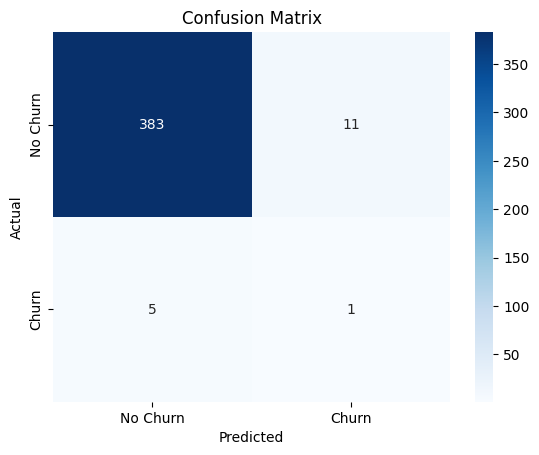

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.99      0.97      0.98       394
       Churn       0.08      0.17      0.11         6

    accuracy                           0.96       400
   macro avg       0.54      0.57      0.55       400
weighted avg       0.97      0.96      0.97       400



TASK - 5


EXPERIMENT 1


In [34]:
model_1 = keras.Sequential([
    layers.Input(shape=(15,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_1 = model_1.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=0
)

test_loss_1, test_acc_1 = model_1.evaluate(X_test, y_test, verbose=0)
print("Experiment 1 Test Accuracy:", test_acc_1)

Experiment 1 Test Accuracy: 0.8149999976158142


EXPERIMENT 2

In [35]:
model_2 = keras.Sequential([
    layers.Input(shape=(15,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_2 = model_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=0
)

test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test, verbose=0)
print("Experiment 2 Test Accuracy:", test_acc_2)

Experiment 2 Test Accuracy: 0.9599999785423279


EXPERIMENT 3

In [36]:
model_3 = keras.Sequential([
    layers.Input(shape=(15,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_3 = model_3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=0
)

test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test, verbose=0)
print("Experiment 3 Test Accuracy:", test_acc_3)

Experiment 3 Test Accuracy: 0.9674999713897705


In [37]:
comparison = pd.DataFrame({
    "Experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "Hidden Layers": [1, 2, 3],
    "Neurons": ["32", "64,32", "128,64,32"],
    "Batch Size": [32, 32, 16],
    "Epochs": [30, 50, 50],
    "Test Accuracy": [test_acc_1, test_acc_2, test_acc_3]
})

comparison

,Experiment,Hidden Layers,Neurons,Batch Size,Epochs,Test Accuracy
0,Exp 1,1,32,32,30,0.8150
1,Exp 2,2,"64,32",32,50,0.9600
2,Exp 3,3,"128,64,32",16,50,0.9675


TASK - 6

## Task 6: CNN Concept Explanation

### What is convolution?
Convolution is a process where a small filter slides across the image to detect features like edges, shapes, and textures.

### Why is pooling used?
Pooling reduces the size of the feature maps, making the model faster and less likely to overfit while keeping the most important information.

### Why is ReLU commonly used?
ReLU removes negative values and allows the network to learn non-linear patterns efficiently without the vanishing gradient problem.

### Why are CNNs better than regular networks for images?
CNNs detect spatial patterns like edges and shapes using filters, which regular dense networks cannot do. CNNs also share weights across the image, making them much more efficient.

## Task 7: Business Use Case

This type of computer vision solution can be used in **manufacturing** for automated visual quality inspection. Instead of human inspectors manually checking products on an assembly line, a CNN model can automatically classify each product as normal, scratched, dented, or stained in real time. This reduces inspection time, lowers costs, and improves defect detection accuracy.